# Transfer learning

This notebook demonstrates how you can use transfer learning within Process Optimizer through the use of XpyriMentor 

The point of transfer learning, is to be able to hot-start optimizations by using data from a system that somehow resembles the system of interest.
In case you are wrong, and the new system is in fact significantly different from the prior, you should still be able to complete the optimization and only be slightly worse of compared to starting from a clean slate.

### Install Botorch

The implementation of transfer learning covered here utilizes `botorch`. Runing the below cell will install `botorch`, if you do not already have it. Installing it will take some time and you might have to restart the Python kernel afterwards.

In [1]:
try:
    import botorch
    print("botorch is already installed.")
except Exception:
    print("Installing botorch")
    %pip install botorch
    import botorch
    print("botorch installed successfully.")

C:\Users\RUCT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


botorch is already installed.


In [2]:
import numpy as np

### Specify test systems

First we specify the test systems.

We will use the Hartman 6D system as ground truth in our initial system. The system we transfer to will be a perturbed version of the Hartman 6D system.

In [3]:
from ProcessOptimizer.model_systems import get_model_system

true_system_init = get_model_system('hart6')

true_system_init.set_noise_model("constant")
true_system_init.noise_model.set_noise_type("Gaussian")
true_system_init.noise_size = 0.1

print(true_system_init.get_score([1,1,0,1,1,1]))  # Example call to get the score

0.030471679850937697


We will also define another system, where we believe that we can transfer learnings between the systems. We do this by loading in a new `hart6` system but then making various pertubations to the input and output. 

In [4]:

true_system_transfer = get_model_system('hart6')

true_system_transfer.set_noise_model("constant")
true_system_transfer.noise_model.set_noise_type("Gaussian")
true_system_transfer.noise_size = 0.1
#true_system_transfer.noise_model.set_noise_type("uniform")
#true_system_transfer.noise_size = 0.2

def score_transfer_system(x, seed=42):
    # Getting some random perturbations and adding them to x
    np.random.seed(seed)
    #x_perturbs = np.random.normal(0, 0.1, 6).tolist()
    #x = [xi + pi for xi, pi in zip(x, x_perturbs)]

    # Adding some scaling to the system as well
    # THIS MAKES IT FAIL
    #x_scaling = np.random.normal(1, 0.2, 6).tolist()
    #x = [xi*si for xi, si in zip(x, x_scaling )]


    y0 = true_system_transfer.get_score(x)
    # Modify y0 with a linear function
    y = 3.*y0 + 17.
    #y = y0

    return y

In [5]:
np.random.seed(42)
x_perturbs = np.random.normal(0, 0.3, 6).tolist()
print(x_perturbs)

[0.14901424590336979, -0.0414792903513554, 0.19430656143020775, 0.45690895692240757, -0.07024601241700079, -0.07024108708475416]


Let us try it out!

In [6]:
x0 = [0.5, 0.5,1,1,1,1]

print(true_system_init.get_score(x0))
print(score_transfer_system(x0))

-0.10506334538765513
17.088220319635514


## Probing the initial system

We start by optimizing within the initial system very much like we would normally do. We perform 20 experiments. They are simply LHS sampling points in the 6 dimensions.

In [7]:
import ProcessOptimizer as po
from ProcessOptimizer import Space

space = [(0.0, 1.0)]*6

opt = po.Optimizer(dimensions=space, n_initial_points = 20)
#opt.acq_func_kwargs = {"xi": 0.5}

We then run the optimizer 40 times for the true system. Buy doing this, we obtain 20 points within the 6D space using latic hypercube sampling. When we exceedd the number of initial points, we start the run the optimizer itself.

array([[<Axes: xlabel='$X_{0}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='$X_{1}$'>,
        <Axes: xlabel='$X_{1}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='$X_{2}$'>, <Axes: >,
        <Axes: xlabel='$X_{2}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='$X_{3}$'>, <Axes: >, <Axes: >,
        <Axes: xlabel='$X_{3}$', ylabel='Dependence'>, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='$X_{4}$'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='$X_{4}$', ylabel='Dependence'>, <Axes: >],
       [<Axes: xlabel='$X_{0}$', ylabel='$X_{5}$'>,
        <Axes: xlabel='$X_{1}$'>, <Axes: xlabel='$X_{2}$'>,
        <Axes: xlabel='$X_{3}$'>, <Axes: xlabel='$X_{4}$'>,
        <Axes: xlabel='$X_{5}$', ylabel='Dependence'>]], dtype=object)

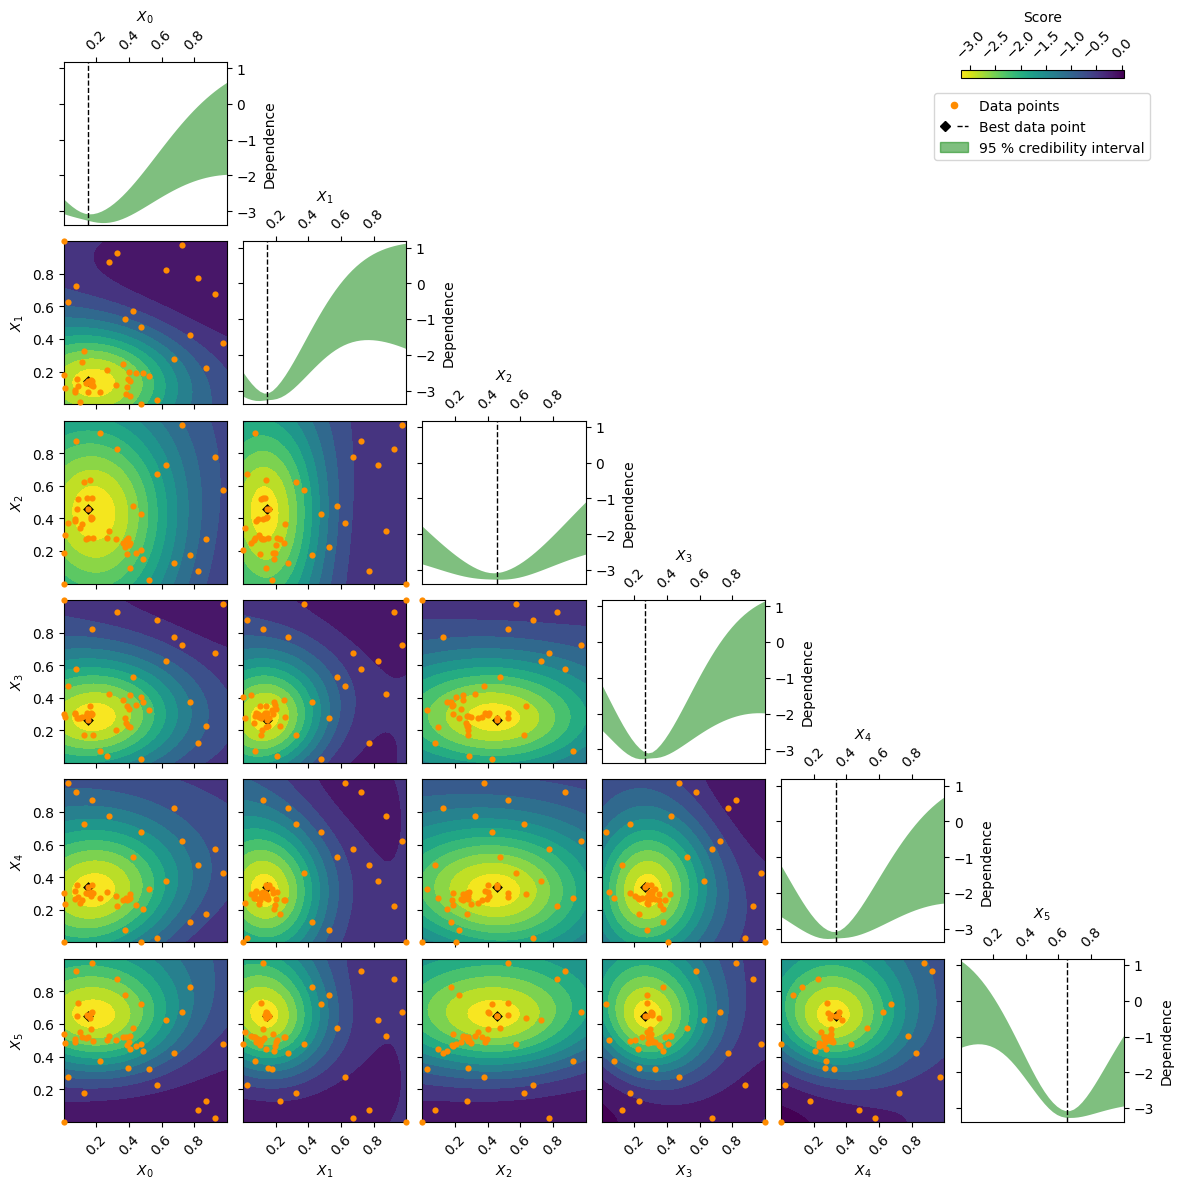

In [8]:
res = opt.run(true_system_init.get_score, n_iter=50)
po.plot_objective(result=res)

In [9]:
xi = res.x_iters
yi = res.func_vals


In [10]:
res

          fun: -3.2406931709066593
            x: [np.float64(0.15105377239058637), np.float64(0.1437902634508371), np.float64(0.45543167112668326), np.float64(0.2631735477815338), np.float64(0.3373546194980622), np.float64(0.6498366088192008)]
    func_vals: [-3.189e-01 -1.311e-01 ...  1.660e-03 -3.008e+00]
      x_iters: [[np.float64(0.775), np.float64(0.425), np.float64(0.175), np.float64(0.375), np.float64(0.125), np.float64(0.825)], [np.float64(0.475), np.float64(0.475), np.float64(0.425), np.float64(0.025), np.float64(0.675), np.float64(0.725)], [np.float64(0.925), np.float64(0.675), np.float64(0.775), np.float64(0.675), np.float64(0.575), np.float64(0.025)], [np.float64(0.825), np.float64(0.775), np.float64(0.075), np.float64(0.125), np.float64(0.475), np.float64(0.075)], [np.float64(0.625), np.float64(0.825), np.float64(0.725), np.float64(0.625), np.float64(0.375), np.float64(0.625)], [np.float64(0.575), np.float64(0.025), np.float64(0.675), np.float64(0.875), np.float64(0.025)

# Multitask from here

We import XpyriMentor and its multitask suggestor

In [11]:
# Necessary functionality from XpyriMentor for TLBO
from ProcessOptimizer import XpyriMentor 
from ProcessOptimizer.XpyriMentor.suggestors import MTSuggestor

In [12]:
[(0.0, 1.0)]*6 + [[0,1,{1}]]

[(0.0, 1.0),
 (0.0, 1.0),
 (0.0, 1.0),
 (0.0, 1.0),
 (0.0, 1.0),
 (0.0, 1.0),
 [0, 1, {1}]]

In [13]:
multitask_space = po.Space([(0.0, 1.0)]*6 + [[0,1,{1}]])

In [14]:
n_objectives = 1
random_seed = 42

hart6_MTSuggestor = MTSuggestor(multitask_space, n_objectives, random_seed)

In [15]:
# XpyriMentor is a maximizer, unlike Optimizer which is a minimizer
yi_pos = [yield_i for yield_i in yi]
#yi_pos = [-yield_i for yield_i in yi]

In [16]:
Transfer_XpyriMentor = XpyriMentor(multitask_space, hart6_MTSuggestor)


In [17]:
Transfer_XpyriMentor.tell(x = xi, y = yi_pos, task = 0)

In [18]:
xi_new = Space(space).lhs(5)
#print(xi_new)
yi_new = [score_transfer_system(x_newi) for x_newi in xi_new]
#yi_new = [-true_system_init.get_score(x_newi) for x_newi in xi_new]
yi_new

[np.float64(16.320030460394964),
 np.float64(17.196533119330432),
 np.float64(17.273252615893036),
 np.float64(15.790686328266975),
 np.float64(16.084582989100355)]

In [19]:
#xi_new

In [20]:
Transfer_XpyriMentor.tell(x = xi_new, y = yi_new, task = 1)

In [21]:
# Pure debugging
#Transfer_XpyriMentor.tell(x = xi_new, y = yi_new, task = 0)  # Notice the 0 here

In [22]:
Transfer_XpyriMentor.ask()

array([[0.18433824, 0.14258076, 0.43521628, 0.2804968 , 0.31303158,
        0.656334  ]], dtype=float32)

In [25]:
for _ in range(20):
    xi_transfer = Transfer_XpyriMentor.ask()
    yi_transfer = [score_transfer_system(xi_transfer)]
    #yi_transfer = [-true_system_init.get_score(xi_transfer)]
    print(xi_transfer)
    print(yi_transfer)
    Transfer_XpyriMentor.tell(x = xi_transfer, y = yi_transfer, task = 1)

[[0.4917462  0.17897402 0.78581256 0.98122793 0.29728153 0.23147836]]
[np.float64(17.232540281806926)]
[[0.5443447  0.27218512 0.8404374  0.9070606  0.355095   0.12411926]]
[np.float64(16.87210280037425)]
[[0.5506474  0.12670067 0.70091575 0.917397   0.4557989  0.17141293]]
[np.float64(16.914123664652042)]
[[0.55174506 0.16105859 1.         0.902099   0.40074322 0.23391134]]
[np.float64(16.76033474642777)]
[[0.33839652 0.18300045 0.8625798  0.9389596  0.4291133  0.15902299]]
[np.float64(17.317471870345646)]
[[0.3518181  0.64406246 0.574752   0.804343   0.4399953  0.54561   ]]
[np.float64(16.61631973675796)]
[[0.7810924  0.88446707 0.49178606 0.58185625 0.30491766 0.7356733 ]]
[np.float64(16.641249904348534)]
[[0.1663982  1.         0.45691502 0.56534255 0.6573979  0.54860437]]
[np.float64(16.67667302880946)]
[[0.4334693  1.         0.5618194  0.2579741  0.51528394 0.5460472 ]]
[np.float64(16.734883820430703)]
[[0.14958191 0.99434346 0.3834804  0.21572672 1.         0.5877979 ]]
[np.flo

In [ ]:
# Find the runs that were for the transfer system
active_task_indices = np.where(np.stack(Transfer_XpyriMentor.Xi)[:, Transfer_XpyriMentor.suggestor.kwargs['surrogate_kwargs']['task_feature']] == 1)[0]

print(active_task_indices)

# Find the maximum value out of those 
best_y = max(np.stack(Transfer_XpyriMentor.yi)[active_task_indices])
print(best_y)

#np.stack(Transfer_XpyriMentor.yi)[active_task_indices]

[ 50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100]
3.3151764191578


array([-0.01553232,  0.11533399, -0.07118133, -0.06149203,  0.20058331,
        0.13021795,  0.27263445,  0.4795168 ,  0.41234722,  0.5011314 ,
        0.33037999,  0.33766082,  0.40928114,  0.30712654,  0.37131735,
        0.50722667,  0.38190846,  0.51769244,  0.33148144,  0.67908833,
        1.18479683,  1.92739781,  1.80823503,  1.56950329,  2.374005  ,
        2.55203229,  2.60827306,  2.85527666,  2.93611303,  2.66305379,
        2.78913916,  2.34378169,  3.18145281,  2.95804235,  3.00761469,
        3.08818891,  3.13927786,  3.31517642,  3.02995958,  2.95780958,
        2.45844461,  3.02881532,  2.85948921,  2.48761197,  3.22604677,
        3.21888412,  3.15224444,  3.21408491,  3.16852727,  3.22870181,
        3.20682772])

In [121]:
Transfer_XpyriMentor.plot_objective()

MemoryError: Unable to allocate 7.72 TiB for an array with shape (101, 101, 101, 101, 101, 101) and data type float64

## VARIOUS CODE SNIPPETS BELOW

In [ ]:
np.random.seed(42)
x_perturbs = np.random.normal(0, 0.2, 6).tolist()
print(x_perturbs)

In [49]:
#for _ in range(20):
#    xi = opt.ask()
#    y = true_system_init.get_score(xi)
#    res = opt.tell(xi,y, fit=True)

#res = opt.fit()

#po.plot_objective(result=res)

In [47]:
#print(res)

#print(len(res.models))

model_fin = res.models[-1]
model0 = res.models[0]

print(model_fin.predict([[0.1, 0.1, 0.1, 0.1, 0.1, 0.1]]))

print(model0.predict([[0.1, 0.1, 0.1, 0.1, 0.1, 0.1]]))


[-0.29951083]
[-0.29951083]
[-0.29951083]
[-0.29951083]
[-0.42427587]
